aapl_historical_data_2026_h1

In [ ]:
import pandas as pd, numpy as np

df = pd.read_csv("aapl_historical_data_2026_h1.csv")
df

# Date - fecha
# Open - precio de apertura
# High - alto del día
# Low - bajo del día
# Close - precio de cierre
# Adj. Close - precio con ajust x dividendos
# Volume - cantidad de operaciones

,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445
...,...,...,...,...,...,...,...
124,2026-06-24,294.55,297.23,292.16,294.85,294.85,45466615
125,2026-06-25,291.25,294.60,289.70,292.22,292.22,69861938
126,2026-06-26,294.96,296.44,294.12,294.77,294.77,78914246
127,2026-06-29,290.30,293.03,288.59,291.41,291.41,54678830


In [ ]:
# Min-Max Open
valor_max_O = df['Open'].max()
valor_min_O = df['Open'].min()

print("Max Open:", valor_max_O)
print("Min Open:", valor_min_O)

# Min-Max High
valor_max_H = df['High'].max()
valor_min_H = df['High'].min()

print("Max High:", valor_max_H)
print("Min High:", valor_min_H)

# Min-Max Low
valor_max_L = df['Low'].max()
valor_min_L = df['Low'].min()

print("Max Low:", valor_max_L)
print("Min Low:", valor_min_L)

# Min-Max Close
valor_max_C = df['Close'].max()
valor_min_C = df['Close'].min()

print("Max Close:", valor_max_C)
print("Min Close:", valor_min_C)

# Min-Max Adj. Close
valor_max_AdjC = df['Close'].max()
valor_min_AdjC = df['Close'].min()

print("Max Adj. Close:", valor_max_AdjC)
print("Min Adj. Close:", valor_min_AdjC)

# Min-Max Volume
valor_max_V = df['Volume'].max()
valor_min_V = df['Volume'].min()

print("Max Volume:", valor_max_V)
print("Min Volume:", valor_min_V)

Max Open: 315.67
Min Open: 246.64
Max High: 318.0
Min High: 248.02
Max Low: 313.09
Min Low: 245.09
Max Close: 315.2
Min Close: 246.61
Max Adj. Close: 315.2
Min Adj. Close: 246.61
Max Volume: 84094405
Min Volume: 35067661


In [ ]:
# columna de U (cambio log de los precios (U=ln(Si/Si-1)))
df["U"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
df

,Date,Open,High,Low,Close,Adj Close,Volume,U
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862,NaN
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103,-0.002764
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862,-0.013410
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033,0.000187
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445,0.000673
...,...,...,...,...,...,...,...,...
124,2026-06-24,294.55,297.23,292.16,294.85,294.85,45466615,-0.004804
125,2026-06-25,291.25,294.60,289.70,292.22,292.22,69861938,-0.008960
126,2026-06-26,294.96,296.44,294.12,294.77,294.77,78914246,0.008688
127,2026-06-29,290.30,293.03,288.59,291.41,291.41,54678830,-0.011464


In [ ]:
# separar U en ventanas de 32 muestras y sacar las medias moviles

df["U_media_movil"] = df["U"].rolling(window=32).mean()
df

# *disclaimer* primeras 31 filas quedan en NaN porque no hay suficiente historia (datos) todavía

,Date,Open,High,Low,Close,Adj Close,Volume,U,U_media_movil_32,U_media_movil
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862,NaN,NaN,NaN
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103,-0.002764,NaN,NaN
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862,-0.013410,NaN,NaN
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033,0.000187,NaN,NaN
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445,0.000673,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
124,2026-06-24,294.55,297.23,292.16,294.85,294.85,45466615,-0.004804,0.000620,0.000620
125,2026-06-25,291.25,294.60,289.70,292.22,292.22,69861938,-0.008960,0.000277,0.000277
126,2026-06-26,294.96,296.44,294.12,294.77,294.77,78914246,0.008688,0.000529,0.000529
127,2026-06-29,290.30,293.03,288.59,291.41,291.41,54678830,-0.011464,-0.000153,-0.000153


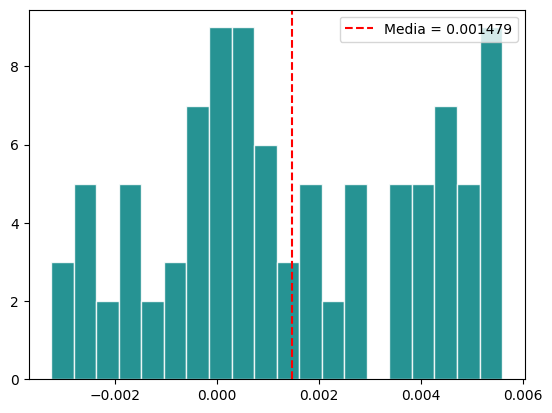

In [54]:
medias_rolling = df["U_media_movil_32"].dropna().to_numpy()  # para quitar los primeros 31 NaN
media_rolling_general = medias_rolling.mean()

plt.hist(medias_rolling, bins=20, color="teal", edgecolor="white", alpha=0.85)
plt.axvline(media_rolling_general, color="red", linestyle="--", label=f"Media = {media_rolling_general:.6f}")
plt.legend()

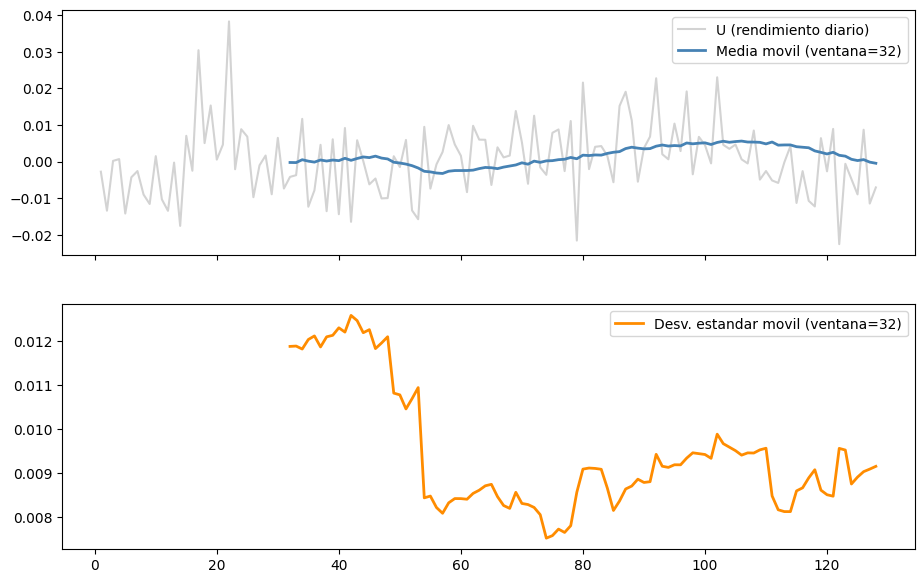

In [53]:
df["U_std_movil_32"] = df["U"].rolling(window=N_VENTANA).std(ddof=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(df.index, df["U"], color="lightgray", label="U (rendimiento diario)")
ax1.plot(df.index, df["U_media_movil_32"], color="steelblue", linewidth=2, label="Media movil (ventana=32)")
ax1.legend()

ax2.plot(df.index, df["U_std_movil_32"], color="darkorange", linewidth=2, label="Desv. estandar movil (ventana=32)")
ax2.legend()

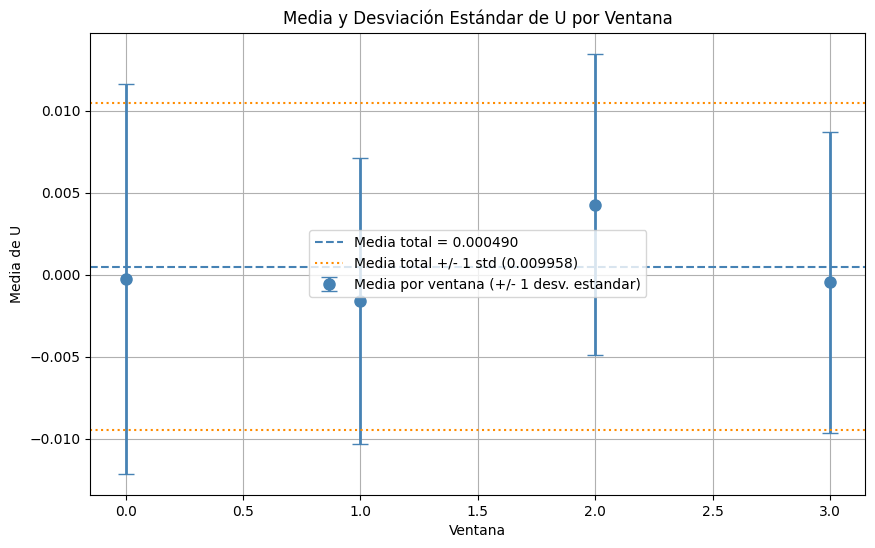

In [55]:
# media de cada ventana vs desv muestral de cada ventana y del toda la info,
import matplotlib.pyplot as plt

stds_por_ventana = ventanas.std(axis=1, ddof=1)
medias_por_ventana = ventanas.mean(axis=1)

media_total = df["U"].mean()
std_total = df["U"].std(ddof=1)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(medias_por_ventana))
ax.errorbar(
    x, medias_por_ventana, yerr=stds_por_ventana,
    fmt="o", color="steelblue", ecolor="steelblue", elinewidth=2, capsize=6, markersize=8,
    label="Media por ventana (+/- 1 desv. estandar)"
)
ax.axhline(media_total, color="steelblue", linestyle="--", label=f"Media total = {media_total:.6f}")
ax.axhline(media_total + std_total, color="darkorange", linestyle=":", label=f"Media total +/- 1 std ({std_total:.6f})")
ax.axhline(media_total - std_total, color="darkorange", linestyle=":")
ax.set_xlabel("Ventana")
ax.set_ylabel("Media de U")
ax.set_title("Media y Desviación Estándar de U por Ventana")
ax.legend()
plt.grid(True)